In [1]:
import os; import jax.numpy as jnp
os.chdir("./src")  


from agent import Agent
from environment import H2ExportEnvironment


2026-02-02 15:53:48,163	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
agent = Agent(solve_date="2026-01-25", solve_id="12-56-56")
env = H2ExportEnvironment(solve_date="2026-01-25", solve_id="12-56-56")

I0000 00:00:1770047633.268869 42747766 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
I0000 00:00:1770047633.275544 42748013 service.cc:152] XLA service 0x3662bef70 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770047633.275553 42748013 service.cc:160]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1770047633.292719 42748013 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


True False 1000 {'constraint_values': Array([[-2.8123050e+00,  1.2821231e+02,  9.4775406e+04,  1.4157259e+05]],      dtype=float32)}


<Figure size 3500x3500 with 0 Axes>

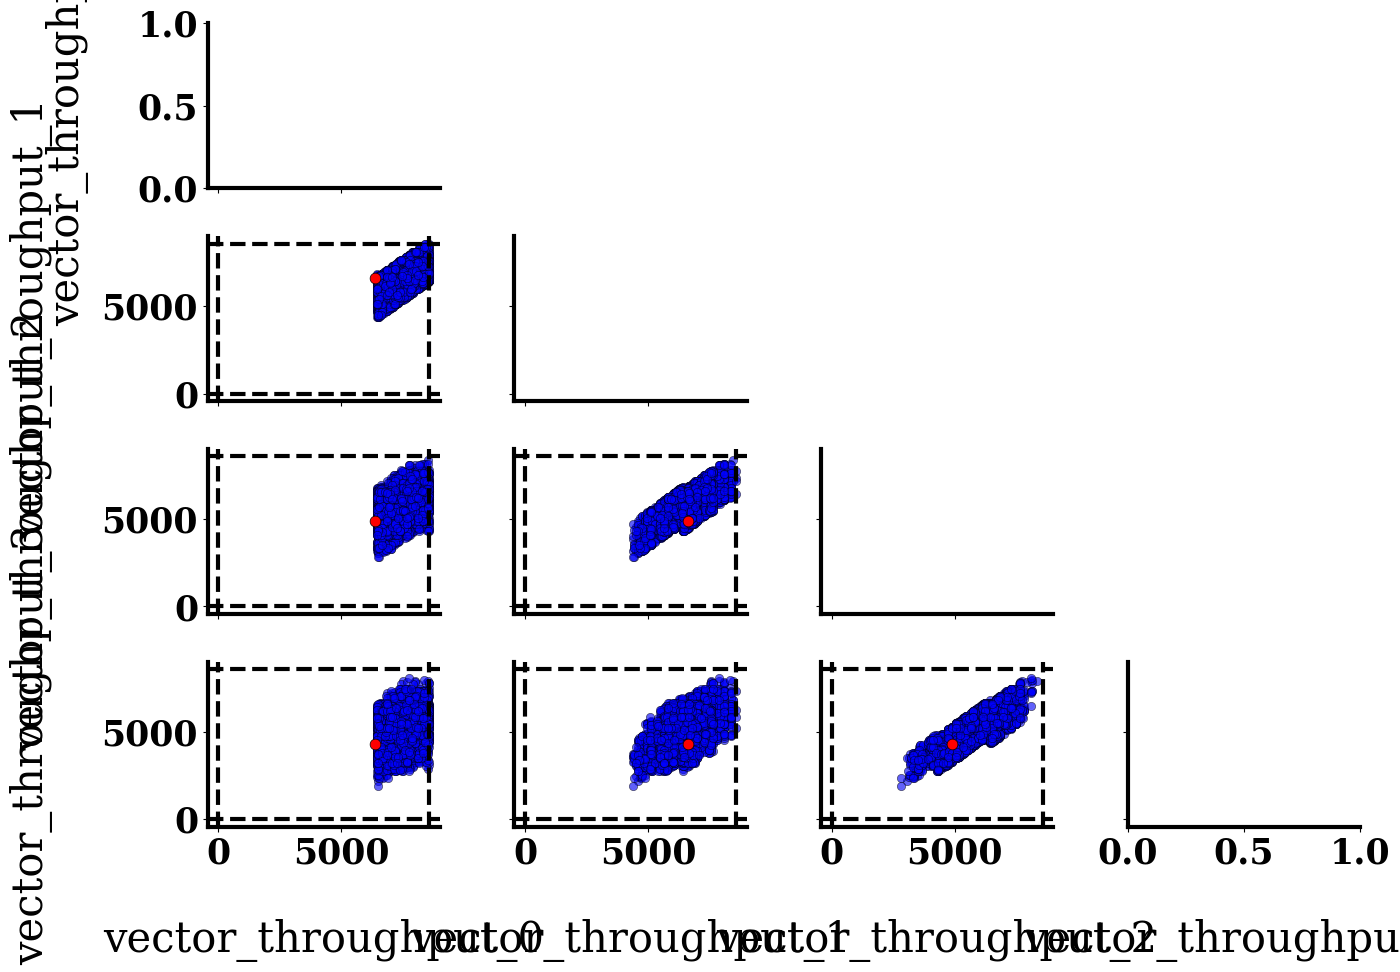

In [3]:
u = env.reset()

net_r = 0
count = 0
while True:
    v = agent.act(u)
    u, r, term, trunc, info = env.step(u, v)
    
    net_r += r
    if term or trunc:
        print(term, trunc, net_r, info)
    count += 1
    if count == 4:
        break
agent.add_policy_to_plot()

In [4]:
agent._actions

deque([(0, Array([[6376.329]], dtype=float32)),
       (1, Array([[6626.075]], dtype=float32)),
       (2, Array([[4893.46]], dtype=float32)),
       (3, Array([[4279.2534]], dtype=float32))])